# Day 10(M3 Day01) 실습 — 임베딩·코사인 유사도와 Vector DB 기초

**목표**: 문장을 임베딩해 벡터로 만들고, 코사인 유사도로 비교하며, 소규모 벡터 저장소로 유사 문장 검색을 구현한다.
**구성**: Part 1 벡터화·유사도(+임베딩 관련 오류 2종) → Part 2 2D 시각화(+직군별 채용 공고 도메인 반복) → Part 3 유사 문장 검색(+교재 11.1 Chroma DB) → Part 3-확장 면접 코치에 지식 검색 추가 → 확장 ② 저장소를 Chroma로 교체

> **참고:** 실습 전 가상환경 활성화, `.env`의 OpenAI API 키를 확인한다. `uv add scikit-learn matplotlib numpy chromadb`가 필요하다. 오늘부터 M3(지식·기억) 모듈이다.

## 0. 환경 준비

In [7]:
import os
os.environ["LANGSMITH_TRACING"] = "false"
os.environ["LANGCHAIN_TRACING_V2"] = "false"

from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
import numpy as np

load_dotenv()

llm = ChatOpenAI(model='gpt-4o-mini')

In [8]:
emb = OpenAIEmbeddings(model='text-embedding-3-small')
emb

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x000001E2206E8110>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x000001E21E181250>, model='text-embedding-3-small', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

## Part 1. 벡터화·유사도 — 기초

완성 코드를 직접 쳐서 문장이 벡터가 되는 과정과, 벡터 사이의 유사도를 확인한다.

### 1-1. 문장 하나 임베딩

한 문장이 1536개 숫자(벡터)가 된다.

In [67]:
# TODO: "강아지가 공원에서 뛰어논다"를 embed_query로 임베딩해 v에 저장하세요
vec = emb.embed_query("강아지가 공원에서 뛰어논다") #고정크기의 수치벡터를 돌려준다.
print(len(vec))
print(vec[:5])

1536
[0.0106964111328125, 0.0149078369140625, 0.00440216064453125, 0.0166473388671875, 0.01296234130859375]


### 1-2. 유사 vs 무관 유사도

거의 같은 뜻은 높고, 무관은 낮다.

In [34]:
#유사도 계산법
#유클리디안거리, 코사인유사도
def cosine(a, b): #리스트 > 넘파이 라이브러리 array : 벡터화 연산 > 유사도 값을 리턴한다.
    # print(type(np.array(a)))
    npa, npb = np.array(a), np.array(b)
    return float(npa @ npb / (np.linalg.norm(a) * np.linalg.norm(b))) #내적/두 벡터 길이의 곱 > 코사인 값

In [69]:
# TODO: [base, near, far]를 embed_documents로 한 번에 임베딩해 vb vn, vf에 저장하세요

base = '강아지가 공원에서 신나게 놀고 있다'
near = '개가 파크에서 즐겁게 뛰어 놀고 있다'
far = '어제 주식시장이 크게 폭락했다'

# base_emb = emb.embed_query(base)
# base_emb[:5]

vb, vn, vf = emb.embed_documents([base, near, far]) # 언패킹
score_1 = cosine(vb, vn) #매개변수 > 수치벡터(리스트), 가까운 의미의 벡터와 유사도 값
score_2 = cosine(vb, vf) #먼값과의 유사도 값

score_1, score_2

(0.31042312783337533, 0.09204448048959633)

### 1-3. 여러 문장 유사도 표

서로의 유사도를 비교한다.

In [70]:
# TODO: sents를 embed_documents로 임베딩해 vs에 저장하세요
# sents = ['어린이가 자란다', '어른이 성장한다', '경제가 좋지 않다']
sents = ['고양이가 잔다', '강아지가 뛴다', '피자가 맛있다']

vs = emb.embed_documents(sents) # 언패킹
for i in range(len(sents)):
    for j in range(i+1, len(sents)):
        print(f'{sents[i]}<>{sents[j]}: {round(cosine(vs[i], vs[j]), 3)}')

고양이가 잔다<>강아지가 뛴다: 0.357
고양이가 잔다<>피자가 맛있다: 0.299
강아지가 뛴다<>피자가 맛있다: 0.205


### 1-4. 유사도 0.5는 '비슷한' 것인가

1-2에서 유사는 0.54, 무관은 0.07이 나왔다. 그러면 **0.5를 기준으로 자르면 될까?** 성격이 다른 다섯 쌍을 재어 본다.


In [71]:
pairs = [
    ("강아지가 공원에서 뛰어논다", "개가 공원에서 뛰어놀고 있다", "거의 같은 뜻"),
    ("환불 절차를 알려주세요", "반품하고 싶어요", "표현은 다르고 의도는 같음"),
    ("강아지가 공원에서 뛰어논다", "고양이가 마당에서 낮잠을 잔다", "같은 분야, 다른 내용"),
    ("환불 절차를 알려주세요", "배송은 언제 오나요", "같은 분야, 다른 의도"),
    ("강아지가 공원에서 뛰어논다", "어제 주식 시장이 폭락했다", "완전 무관"),
]

for a, b, label in pairs:
    # TODO: a와 b를 embed_documents로 한 번에 임베딩하고, cosine으로 유사도를 출력하세요
    va, vb = emb.embed_documents([a, b])
    print(f"{cosine(va, vb):.3f}  {label:<18} | {a} <-> {b}")


0.599  거의 같은 뜻            | 강아지가 공원에서 뛰어논다 <-> 개가 공원에서 뛰어놀고 있다
0.261  표현은 다르고 의도는 같음     | 환불 절차를 알려주세요 <-> 반품하고 싶어요
0.402  같은 분야, 다른 내용       | 강아지가 공원에서 뛰어논다 <-> 고양이가 마당에서 낮잠을 잔다
0.209  같은 분야, 다른 의도       | 환불 절차를 알려주세요 <-> 배송은 언제 오나요
0.071  완전 무관              | 강아지가 공원에서 뛰어논다 <-> 어제 주식 시장이 폭락했다


In [72]:
pairs = [
    ("스파이더맨은 톰홀랜드이다.", "톰홀랜드는 스파이더맨이다", "거의 같은 뜻"),
    ("스파이더맨4 개봉일 알려주세요.", "스파이더맨4 영화 보러가고 싶어요.", "표현은 다르고 의도는 같음"), 
    ("아이언맨의 수트 종류에 대해 알려줘.", "캡틴 아메리카의 방패 재질에 대해 알려줘.", "같은 분야, 다른 내용"),
    ("어벤져스 엔드게임 출연진 알려줘.", "어벤져스 엔드게임 제작비랑 흥행 수익 알려줘.", "같은 분야, 다른 의도"),
    ("스파이더맨이 뉴욕 빌딩을 날아다닌다.", "어제 주식 시장이 폭락했다", "완전 무관"),
]

for a, b, label in pairs:
    # TODO: a와 b를 embed_documents로 한 번에 임베딩하고, cosine으로 유사도를 출력하세요
    va, vb = emb.embed_documents([a, b])
    print(f"{cosine(va, vb):.3f}  {label:<18} | {a} <-> {b}")

0.593  거의 같은 뜻            | 스파이더맨은 톰홀랜드이다. <-> 톰홀랜드는 스파이더맨이다
0.717  표현은 다르고 의도는 같음     | 스파이더맨4 개봉일 알려주세요. <-> 스파이더맨4 영화 보러가고 싶어요.
0.288  같은 분야, 다른 내용       | 아이언맨의 수트 종류에 대해 알려줘. <-> 캡틴 아메리카의 방패 재질에 대해 알려줘.
0.694  같은 분야, 다른 의도       | 어벤져스 엔드게임 출연진 알려줘. <-> 어벤져스 엔드게임 제작비랑 흥행 수익 알려줘.
0.083  완전 무관              | 스파이더맨이 뉴욕 빌딩을 날아다닌다. <-> 어제 주식 시장이 폭락했다


> ⚠️ **순서가 뒤집혔다.** "표현은 다르고 의도는 같음"(0.261)이 "같은 분야, 다른 내용"(0.402)보다 **낮다.** 우리가 찾고 싶은 쪽이 더 낮게 나온 것이다.
>
> 임베딩 유사도는 **주제가 얼마나 겹치는가**를 주로 본다. 의도가 같은지는 그다음이다. 그래서 `유사도 > 0.5면 관련 있음` 같은 **고정 임계값은 도메인이 바뀌면 바로 깨진다.** 실무에서는 절대값으로 자르지 말고 **상위 k개를 순위로 뽑는다.** Part 3의 `search(query, k=2)`가 그래서 k를 받는다.


### 1-5. 키워드 검색과 무엇이 다른가

단어가 겹치는 비율(키워드 검색이 보는 것)과 임베딩 유사도를 나란히 재어 본다. 임베딩의 힘과 한계가 한 표에 같이 나온다.


In [73]:
def keyword_score(a, b):
    """단어가 얼마나 겹치는지 - 키워드 검색이 보는 것"""
    # TODO: 두 문장을 split()으로 단어 집합으로 만들고, 교집합 크기 / 합집합 크기를 돌려주세요
    sa, sb = set(a.split()), set(b.split()) # set : 중복이 없는 집합
    return len(sa & sb) / len(sa | sb)


cases = [
    ("돈 돌려받고 싶어요", "환불은 구매 후 7일 이내 가능합니다"),
    ("택배 언제 와요?", "배송은 보통 2~3일 걸립니다"),
    ("환불이 가능합니다", "환불이 불가능합니다"),
    ("사과를 먹었다", "사과를 하러 갔다"),
]

In [74]:
print(f"{'키워드':>7}{'임베딩':>8}   문장 쌍")
for a, b in cases:
    va, vb = emb.embed_documents([a, b])
    print(f"{keyword_score(a, b):>7.2f}{cosine(va, vb):>8.3f}   {a} <-> {b}")

    키워드     임베딩   문장 쌍
   0.00   0.254   돈 돌려받고 싶어요 <-> 환불은 구매 후 7일 이내 가능합니다
   0.00   0.334   택배 언제 와요? <-> 배송은 보통 2~3일 걸립니다
   0.33   0.852   환불이 가능합니다 <-> 환불이 불가능합니다
   0.25   0.723   사과를 먹었다 <-> 사과를 하러 갔다


In [75]:
# 도메인 질문의 키워드 스코어와 임베딩 유사도 비교
cases_1 = [
    ("스파이더맨은 톰홀랜드이다.", "톰홀랜드는 스파이더맨이다", "거의 같은 뜻"),
    ("스파이더맨4 개봉일 알려주세요.", "스파이더맨4 영화 보러가고 싶어요.", "표현은 다르고 의도는 같음"), 
    ("아이언맨의 수트 종류에 대해 알려줘.", "캡틴 아메리카의 방패 재질에 대해 알려줘.", "같은 분야, 다른 내용"),
    ("어벤져스 엔드게임 출연진 알려줘.", "어벤져스 엔드게임 제작비랑 흥행 수익 알려줘.", "같은 분야, 다른 의도"),
    ("스파이더맨이 뉴욕 빌딩을 날아다닌다.", "어제 주식 시장이 폭락했다", "완전 무관"),
]

print(f"{'키워드':>7}{'임베딩':>8}   문장 쌍")
for a, b, C in cases_1:
    va, vb = emb.embed_documents([a, b])
    print(f"{keyword_score(a, b):>7.2f}{cosine(va, vb):>8.3f}   {a} <-> {b}")

    키워드     임베딩   문장 쌍
   0.00   0.593   스파이더맨은 톰홀랜드이다. <-> 톰홀랜드는 스파이더맨이다
   0.17   0.717   스파이더맨4 개봉일 알려주세요. <-> 스파이더맨4 영화 보러가고 싶어요.
   0.22   0.288   아이언맨의 수트 종류에 대해 알려줘. <-> 캡틴 아메리카의 방패 재질에 대해 알려줘.
   0.43   0.694   어벤져스 엔드게임 출연진 알려줘. <-> 어벤져스 엔드게임 제작비랑 흥행 수익 알려줘.
   0.00   0.083   스파이더맨이 뉴욕 빌딩을 날아다닌다. <-> 어제 주식 시장이 폭락했다


관찰할 것이 두 가지다.

**위 두 줄 — 임베딩이 이긴다.** 단어가 하나도 안 겹쳐 키워드 점수는 0.00인데, 임베딩은 0.25·0.33으로 관계를 잡아낸다. Part 3의 유사 문장 검색이 되는 이유가 이것이다.

**아래 두 줄 — 임베딩이 진다.**

> ⚠️ `"환불이 가능합니다"`와 `"환불이 **불**가능합니다"`의 유사도가 **0.852**다. 뜻이 정반대인데 가장 비슷한 쌍으로 나온다. 임베딩은 **부정(否定)을 거의 구분하지 못한다.** `"사과를 먹었다"`와 `"사과를 하러 갔다"`도 0.723 — 같은 글자면 다른 뜻이어도 가깝게 본다.

그래서 실무에서는 키워드 검색과 임베딩 검색을 **함께** 쓴다. 이것이 M3 Day04(Day13)의 하이브리드 검색이다.


### 1-6. 왜 하필 '코사인'인가 — 길이와 내적

`cosine()` 안에서 내적을 길이로 나누고 있었다. 그 나눗셈이 무슨 일을 하는지 확인한다.


In [76]:


# TODO: np.linalg.norm으로 v의 길이를, @로 내적을 구해 코사인과 나란히 출력하세요

# TODO: v_long과 w의 내적, 코사인을 각각 출력하고 위 값과 비교하세요




**OpenAI 임베딩은 길이가 1로 맞춰져 나온다.** 그래서 내적(0.5986)과 코사인(0.5987)이 사실상 같다.

길이를 3배로 늘리면 차이가 드러난다. 내적은 3배가 되지만 코사인은 그대로다. **코사인은 크기를 무시하고 방향만 본다.** 문장이 길어 벡터 크기가 커져도 "무슨 의미인가"만 비교하려는 것이다.

> **참고:** 길이가 1로 정규화된 벡터끼리는 내적과 코사인이 같으므로, 정규화를 전제한 시스템은 더 싼 내적(`ip`)을 쓰기도 한다. 이 선택이 Vector DB 설정으로 나오는 것을 3-3에서 본다.


### 1-7. 무엇이 유사도를 흔드나

같은 질문을 여러 방식으로 바꿔 쓰고, 원문과의 유사도가 얼마나 떨어지는지 본다. 실제 사용자 입력이 이렇게 들어온다.


In [77]:
# TODO: base를 embed_query로 벡터화한 뒤, 각 variant와의 유사도를 출력하세요
base = "환불 절차를 알려주세요"
variant = [
    {"띄어쓰기 없음", "환불절차를알려주세요"},
    {"오타", "환불 절차를 알려주새요"},
    {"어순 바꿈", "알려주세요 환불 절차를"},
    {"반말", "환불 절차 알려줘"},
    {"영어", "How do I get a refund"},
    {"같은 분야 다른 질문", "배송 조회는 어떻게 하나요?"}
]

In [78]:
vb = emb.embed_query(base)

for label, text in variant:
    vtext = emb.embed_query(text)
    print(f"{cosine(vb, vtext):.3f} {label:<20} {text}")

0.268 환불절차를알려주세요           띄어쓰기 없음
0.922 오타                   환불 절차를 알려주새요
0.168 알려주세요 환불 절차를         어순 바꿈
0.223 환불 절차 알려줘            반말
0.202 How do I get a refund 영어
0.204 같은 분야 다른 질문          배송 조회는 어떻게 하나요?


**오타(0.922)와 반말(0.931)에는 강하다.** 키워드 검색이라면 오타 하나로 못 찾았을 것이다. 사용자가 대충 입력해도 찾아낸다는 뜻이다.

**어순을 바꾸면 0.608까지 떨어진다.** 같은 단어로 이뤄졌는데도 그렇다. 임베딩은 단어 주머니가 아니라 문장 전체의 짜임을 본다.

> ⚠️ **영어로 바꾸면 0.300이다.** 뜻은 완전히 같은 문장인데 "같은 분야 다른 질문"(0.214)보다 조금 높은 수준이다. 이 모델의 언어 간 정렬은 기대만큼 강하지 않다. **다국어 서비스라면 반드시 직접 재 보고 모델을 골라야 한다.** "임베딩은 의미를 보니까 언어가 달라도 되겠지"가 가장 흔한 오해다.


### 1-8. 오류 대응 ① — 빈 문자열을 임베딩하면?

실무에서는 사용자가 빈 입력을 보낼 수 있다. 빈 문자열을 그대로 임베딩하면 어떻게 되는지 직접 확인한다.

In [ ]:
# TODO: 빈 문자열 ""을 embed_query로 임베딩해 v_empty에 저장하세요
v_emb = emb.embed_query("") # 에러나지 않는다
print(v_emb)

> **주의:** 결과는 실제 실행에서 직접 확인한다. 빈 입력이 예외 없이 통과된다면, 서비스 코드에서는 빈 문자열을 미리 걸러내는 검증이 필요하다는 뜻이다.

### 1-9. 오류 대응 ② — embed_query와 embed_documents를 바꿔 쓰면?

`embed_documents`는 문장 **목록(list)** 을 받는다. 실수로 문자열 하나를 그대로 넣으면 무슨 일이 일어나는지 확인한다.

In [80]:
# TODO: text_by_mistake를 embed_documents에 그대로 넣어 weird_vectors에 저장하세요

q = "강아지가 뛴다"
result = emb.embed_documents(q) 
len(result) # q 문자열을 각각 한글자씩 잘랐다.
# result[:1]

7

#### 수정한 버전

문장이 1개인지 목록인지에 따라 쓰는 메서드가 다르다. 두 방식의 결과가 같은 벡터인지도 함께 확인한다.

In [81]:
result = emb.embed_query(q)
len(result)

1536

> **주의:** 파이썬 문자열은 한 글자씩 순회(iterate)할 수 있는 값이다. `embed_documents`에 리스트 대신 문자열을 넣으면 **에러 없이** 글자 하나하나가 각각 임베딩된다 — 겉보기엔 실행이 되니 알아채기 더 어려운 실수다. 반드시 `[text_by_mistake]`처럼 리스트로 감싸야 한다.

### 1-10. 오류 대응 ③ — 차원을 줄이면? 섞으면?

`text-embedding-3-small`은 `dimensions`로 벡터 차원을 줄일 수 있다. 저장 공간과 계산이 싸지는 대신 무엇을 잃는지 확인한다.


In [4]:
# TODO: dimensions=512로 OpenAIEmbeddings를 하나 더 만드세요
emb512 = OpenAIEmbeddings(model="text-embedding-3-small", dimensions=512)
sents = ['환불 절차를 알려주세요', '반품하고 싶어요.', '배송은 언제 오나요', '어제 주식 시장이 폭락했다']

v1536 = emb.embed_documents(sents)
v512 = emb512.embed_documents(sents)


In [5]:
len(v512[0]), len(v1536[0])

(512, 1536)

In [12]:
print(f"base :  {sents[0]}")
for i in range(1, len(sents)):
    print(f"{cosine(v512[0], v512[i]):>10.3f}, {cosine(v1536[0], v1536[i]):>10.3f} > {sents[i]}")

base :  환불 절차를 알려주세요
     0.332,      0.265 > 반품하고 싶어요.
     0.205,      0.209 > 배송은 언제 오나요
     0.247,      0.198 > 어제 주식 시장이 폭락했다


In [20]:
# 내 도메인의 문장 512 vs 1536 각각의 유사도로 비교하기
sents = ['스파이더맨4 개봉일 알려주세요.', '스파이더맨4 영화 보러가고 싶어요.', '어벤져스 엔드게임 출연진 알려줘.', '어제 주식 시장이 폭락했다']

v1536 = emb.embed_documents(sents)
v512 = emb512.embed_documents(sents)

print(f"base :  {sents[0]}")
print(f"{'v512':>7}{'v1536':>13}        문장")
for i in range(1, len(sents)):
    print(f"{cosine(v512[0], v512[i]):>10.3f}, {cosine(v1536[0], v1536[i]):>10.3f} > {sents[i]}")

base :  스파이더맨4 개봉일 알려주세요.
   v512        v1536        문장
     0.704,      0.717 > 스파이더맨4 영화 보러가고 싶어요.
     0.311,      0.291 > 어벤져스 엔드게임 출연진 알려줘.
     0.154,      0.104 > 어제 주식 시장이 폭락했다


> ⚠️ **순위가 뒤집혔다.** 1536차원에서는 "배송은 언제 오나요"(0.209)가 "어제 주식 시장이 폭락했다"(0.198)보다 위였다. 512차원에서는 주식(0.247)이 배송(0.205)을 앞선다. **완전히 무관한 문장이 같은 분야 문장보다 가까워진 것이다.** 차원을 줄이면 싸지지만 이렇게 어긋날 수 있다.

**그리고 차원이 다른 벡터끼리는 아예 비교가 안 된다.** `ValueError`가 난다.

이것이 실무에서 가장 크게 터지는 사고다. 문서 10만 건을 `text-embedding-3-small`로 저장해 두고, 나중에 검색 쪽 코드만 다른 모델로 바꾸면 — 차원이 같으면 **에러도 없이 엉뚱한 결과**가 나온다. **저장할 때와 검색할 때의 임베딩 모델과 설정은 반드시 같아야 한다.** Vector DB에 컬렉션 단위로 모델을 고정하는 이유다.


### 관찰 정리

- 유사도 절대값으로 임계값을 정하면 왜 위험한가? 대신 무엇을 쓰는가? (1-4)
- 단어가 안 겹쳐도 찾아내는 것이 임베딩의 힘이라면, 한계는 무엇이었나? (1-5)
- 내적이 아니라 코사인을 쓰는 이유는 무엇인가? (1-6)
- 오타·반말에는 강했고 영어에는 약했다. 다국어 서비스라면 무엇을 먼저 확인해야 하는가? (1-7)
- 빈 문자열·타입 실수처럼 겉으로 티가 안 나는 입력 문제는 무엇으로 미리 막을 수 있을까? (1-8·1-9)
- 저장할 때와 검색할 때 임베딩 설정이 다르면 무슨 일이 일어나는가? (1-10)


## Part 2. 임베딩 2D 시각화 — 응용

1536차원 벡터를 2차원으로 줄여(PCA) 의미 군집을 눈으로 확인한다.

### 2-1. 준비 — 한글 폰트와 도우미 함수

Windows에서 matplotlib 한글이 □로 나오는 것을 막고, Part 2 내내 쓸 함수 두 개를 만들어 둔다. `draw`는 점을 찍고, `most_similar`는 가장 비슷한 문장을 찾는다.


In [16]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 한글 폰트
plt.rcParams["axes.unicode_minus"] = False

In [17]:
def draw(coords, texts, labels, colors, title):
    """카테고리별로 색을 나눠 점을 찍고, 점 옆에 문장을 적는다."""
    plt.figure(figsize=(7, 5))
    done = []                                   # 범례에 이미 올린 카테고리
    for i in range(len(texts)):
        g = labels[i]
        if g in done:
            plt.scatter(coords[i][0], coords[i][1], color=colors[g], s=60)
        else:
            # 같은 카테고리가 범례에 여러 번 나오지 않게, 처음 한 번만 label을 준다
            plt.scatter(coords[i][0], coords[i][1], color=colors[g], s=60, label=g)
            done.append(g)
        plt.annotate(texts[i], (coords[i][0], coords[i][1]), fontsize=8)
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.show()


def most_similar(qv, vectors, texts):
    """qv와 가장 비슷한 문장을 (유사도, 문장)으로 돌려준다. Part 3의 search()와 같은 방식이다."""
    scored = [(cosine(qv, v), t) for v, t in zip(vectors, texts)]
    scored.sort(reverse=True)
    return scored[0]

### 2-2. PCA 2D 시각화 — 동물/음식/스포츠

1536차원을 2차원으로 줄이고, 카테고리별 색으로 찍는다.

#### 먼저 작은 예 — 숫자 2개를 1개로

1536개는 너무 크다. 숫자 2개짜리 데이터로 먼저 본다. 사람 5명의 키·몸무게다.

다음 코드를 실행하고 결과를 확인합니다.

In [10]:
from sklearn.decomposition import PCA # 차원 축소 알고리즘

# 사람 5명 = [키(cm), 몸무게(kg)] - 숫자 2개짜리 데이터
people = np.array([
    [160, 55],
    [165, 57],
    [170, 68],
    [175, 66],
    [180, 78],
])

# PCA 로 차원 축소 : 숫자 2개 -> 1개로 줄인다
pca1 = PCA(n_components=1)
reduced = pca1.fit_transform(people)
print(reduced)


[[-13.94003932]
 [ -9.18465496]
 [  2.4437355 ]
 [  4.14445048]
 [ 16.53650829]]


In [29]:
pca1.explained_variance_ratio_

array([0.97045716])

In [32]:
# 줄인 숫자 1개로 원래 2개를 되돌려본다 - 얼마나 어긋나는지가 곧 잃은 정보다
restored = pca1.inverse_transform(reduced)
restored

array([[161.00017214,  54.15444719],
       [164.07029552,  57.78597893],
       [171.57769992,  66.666201  ],
       [172.6756984 ,  67.9649815 ],
       [180.67613402,  77.42839138]])

In [25]:
print(people)

[[160  55]
 [165  57]
 [170  68]
 [175  66]
 [180  78]]


#### 무슨 일이 일어났나

키와 몸무게는 따로 노는 숫자가 아니다. 키가 크면 몸무게도 큰 경향이 있다 → 두 숫자가 사실상 **체격** 하나를 말하고 있었다. PCA는 그 "하나"를 찾아낸다.

남은 숫자 1개가 쓸 만한지 확인하는 방법은 **복원**이다. 그 1개로 원래 2개를 되돌려 원본과 비교한다.

| 원본 | 복원 | 어긋난 정도 |
| --- | --- | --- |
| 160cm 55kg | 161.0cm 54.2kg | 1cm 안팎 |
| 180cm 78kg | 180.7cm 77.4kg | 1kg 안팎 |
| 175cm 66kg | 172.7cm 68.0kg | 2cm, 2kg |

숫자를 절반으로 버렸는데 원본이 거의 그대로 돌아온다. **"살아남은 정보 97.0%"가 뜻하는 게 이것이다.**

가장 많이 어긋난 건 4번(175cm 66kg)이다. 키에 비해 가벼워 **체격 하나로는 설명되지 않는 사람** → 버려진 3%가 이런 부분이다.

> ⚠️ **줄인 값 -13.9는 키도 몸무게도 아니다.** 단위가 없는 상대 위치일 뿐이다. 그래서 **누가 누구와 가까운가**만 읽는다.

#### 차원 축소(PCA)란

**PCA(Principal Component Analysis, 주성분 분석)** 는 방금 한 일을 일반화한 것이다. 비유하면 **그림자**다. 입체인 주전자를 벽에 비추면 2차원 그림자가 생기는데, 각도에 따라 모양이 달라진다. PCA는 점들이 **가장 넓게 퍼져 보이는 각도**를 찾아 그 각도의 그림자만 남긴다.

이제 같은 일을 문장 임베딩에 한다. 2개를 1개로가 아니라, 1536개를 2개로 줄인다.

| 항목 | 키·몸무게 예시 | 문장 임베딩 |
| --- | --- | --- |
| 입력 | 5명 × 숫자 2개 | 문장 12개 × 숫자 1536개 |
| 출력 | 5명 × 숫자 1개 | 문장 12개 × 숫자 2개 (x, y 좌표) |
| 살아남는 정보 | 97% | 약 32% |

> ⚠️ **1536 → 2는 손실이 크다.** 68%를 버린 그림이라 일부 점이 어긋나는 게 정상이다.

> 💡 PCA는 **눈으로 보려고** 쓴다. 유사도 계산과 검색(Part 3)은 줄이지 않은 1536차원 원본으로 한다.

> **참고:** 같은 색(카테고리)끼리 대체로 모이면 임베딩이 의미를 담고 있다는 뜻이다.

In [22]:
# TODO: texts를 embed_documents로 임베딩한 뒤 PCA로 2차원(xy)으로 줄이세요
# TODO: vecs.shape와 xy.shape를 출력해 1536개 -> 2개로 줄었는지 확인하세요

from sklearn.decomposition import PCA

groups = {
    "동물": ["강아지가 귀엽게 뛰어논다", "고양이가 소파에서 잔다", "토끼가 풀밭을 뛴다", "강아지가 짖는다"],
    "음식": ["김치찌개가 매콤하다", "피자가 정말 맛있다", "초밥이 신선하다", "라면이 짜다"],
    "스포츠": ["축구 경기가 열렸다", "농구 선수가 슛을 쐈다", "야구 경기를 봤다", "마라톤을 완주했다"],
}
#
texts, labels = [], []
for g, ss in groups.items():
    for s in ss:
        texts.append(s); labels.append(g)


In [23]:
texts

['강아지가 귀엽게 뛰어논다',
 '고양이가 소파에서 잔다',
 '토끼가 풀밭을 뛴다',
 '강아지가 짖는다',
 '김치찌개가 매콤하다',
 '피자가 정말 맛있다',
 '초밥이 신선하다',
 '라면이 짜다',
 '축구 경기가 열렸다',
 '농구 선수가 슛을 쐈다',
 '야구 경기를 봤다',
 '마라톤을 완주했다']

In [24]:
labels

['동물', '동물', '동물', '동물', '음식', '음식', '음식', '음식', '스포츠', '스포츠', '스포츠', '스포츠']

In [25]:
vecs = np.array(emb.embed_documents(texts))
vecs[:5]

array([[ 0.02281189,  0.01284027, -0.02253723, ...,  0.03372192,
        -0.01724243, -0.00457764],
       [ 0.01333618, -0.00869751, -0.04559326, ...,  0.02297974,
        -0.00309181, -0.01301575],
       [ 0.01052856,  0.00569534,  0.00972748, ...,  0.04464722,
        -0.01111603,  0.00319481],
       [ 0.01564026,  0.0324707 ,  0.01364136, ...,  0.0075264 ,
         0.00525284, -0.00711441],
       [ 0.01852417, -0.06872559, -0.03152466, ...,  0.02194214,
         0.00783539, -0.02023315]], shape=(5, 1536))

In [26]:
xy = PCA(n_components=2).fit_transform(vecs)
xy.shape, vecs.shape

((12, 2), (12, 1536))

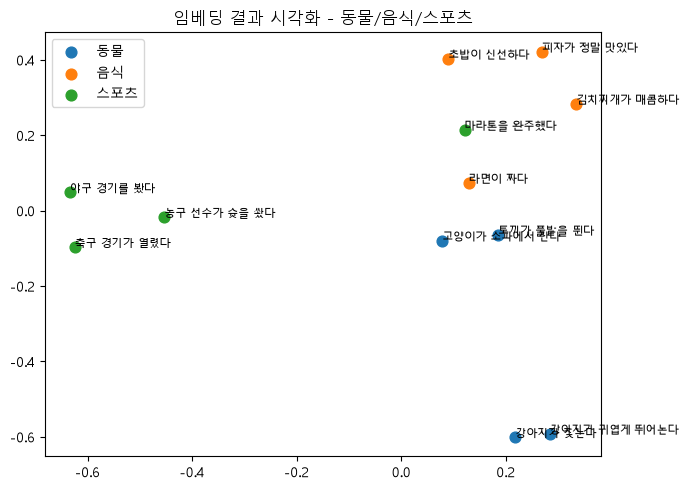

In [27]:
colors = {"동물":"tab:blue", "음식": "tab:orange", "스포츠":"tab:green"}
draw(xy, texts, labels, colors, "임베딩 결과 시각화 - 동물/음식/스포츠")

### 관찰

| 관찰 | 의미 |
| --- | --- |
| 같은 색이 모임 | 임베딩이 의미를 반영 |
| 일부 점은 어긋남 | 2D로 줄이며 정보 손실 + 짧은 문장의 한계 |

### 2-3. 다른 도메인 반복 — 직군별 채용 공고 설명

같은 방법을 다른 도메인에도 적용해본다. 이번엔 직군별 업무 설명 문장으로 같은 시각화를 반복한다 — Part 3의 지식 검색 확장과도 이어진다.

In [1]:
# TODO: texts2를 embed_documents로 임베딩하고 PCA로 2차원(xy2)으로 줄이세요
groups2 = {
    "백엔드 개발자": ["Python으로 API 서버를 만든다", "데이터베이스 쿼리를 최적화한다", "서버 배포와 운영을 담당한다", "동시성 문제를 해결한다"],
    "프론트엔드 개발자": ["React로 화면을 만든다", "반응형 레이아웃을 구현한다", "사용자 경험을 개선한다", "웹 접근성을 준수한다"],
    "데이터 분석가": ["SQL로 데이터를 추출한다", "통계로 트렌드를 분석한다", "대시보드를 만든다", "실험 결과를 해석한다"],
    "마케터": ["콘텐츠 캠페인을 기획한다", "SNS 채널을 운영한다", "광고 성과를 분석한다", "타겟 고객을 정의한다"],
}

In [ ]:
# 1. texts(임베딩 대상), label(그룹명)로 나눠서
texts2, labels2 = [], []
for g, ss in groups2.items():
    for s in ss:
        texts2.append(s); labels2.append(g)

In [ ]:
# 2. texts를 임베딩 > (16, 1536)
vecs2 = np.array(emb.embed_documents(texts2))

In [ ]:
# 3. PCA로 차원축소 2개로
xy2 = PCA(n_components=2).fit_transform(vecs2)

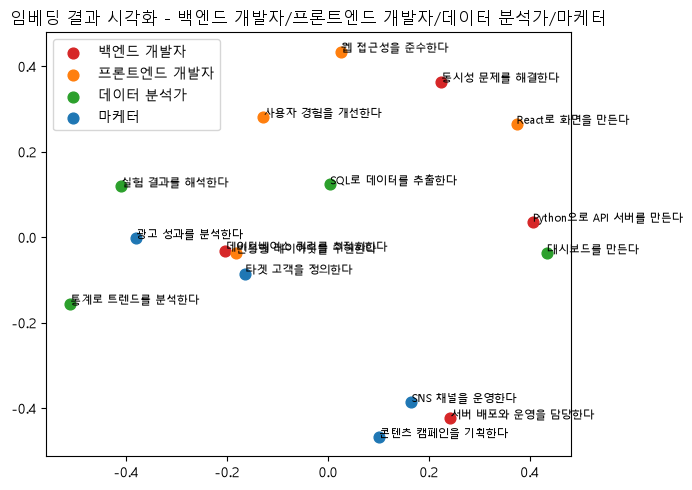

In [ ]:
# 4. draw() 그려서 확인
colors2 = {"백엔드 개발자":"tab:red", "프론트엔드 개발자":"tab:orange", "데이터 분석가":"tab:green", "마케터":"tab:blue"}
draw(xy2, texts2, labels2, colors2, "임베딩 결과 시각화 - 백엔드 개발자/프론트엔드 개발자/데이터 분석가/마케터")

### 2-4. 이 그림을 얼마나 믿을 수 있나

2-2에서 1536개를 2개로 줄였다. **얼마나 버린 것인가.** 숫자로 확인한다.


In [28]:
# TODO: PCA(n_components=10)으로 vecs를 학습시키고 explained_variance_ratio_를 꺼내세요
pca10 = PCA(n_components=10).fit(vecs)
ratios_10 = pca10.explained_variance_ratio_

pca2 = PCA(n_components=2).fit(vecs)
ratios_2 = pca2.explained_variance_ratio_

print(ratios_10, ratios_2)

# TODO: np.cumsum(ratios) * 100 을 cum에 담고 plt.plot으로 꺾은선을 그리세요




[0.16903653 0.14669325 0.10845475 0.09847696 0.09476131 0.08707087
 0.07584683 0.07567019 0.06835908 0.04152423] [0.16903653 0.14669325]


In [30]:
cum = np.cumsum(ratios_10) * 100 # np의 합산
cum #96.5% 의 특성

array([16.903653  , 31.5729776 , 42.41845249, 52.26614872, 61.74227931,
       70.44936674, 78.03404982, 85.60106879, 92.43697687, 96.58940027])

**2D 그림은 원본 정보의 31.6%만 담고 있다.** 68%를 버린 그림이다.

키·몸무게 예시는 2개를 1개로 줄이고도 97%가 살아남았다. 키와 몸무게는 사실상 체격 하나를 말하고 있었기 때문이다. 문장 임베딩의 1536개는 그렇게 한두 방향으로 모이지 않는다. 그래서 축을 10개까지 늘려도 곡선이 천천히만 올라간다.

> ⚠️ **그림이 예쁘게 나왔다고 임베딩이 좋은 것이 아니고, 그림에서 겹쳤다고 임베딩이 나쁜 것도 아니다.** 2-5에서 이것을 직접 확인한다.


### 2-5. 그림에서 가까우면 실제로도 가까운가

68%를 버렸다면, 그림 위의 거리를 믿어도 될까. **그림에서 잰 거리**와 **1536차원에서 잰 진짜 유사도**를 나란히 놓고 본다.


In [88]:

# TODO: 그림 위 거리(xy)와 1536차원 유사도(vecs)를 각각 구하세요



# TODO: 유사도를 앞에 놓은 목록 by_sim을 만들고 내림차순 정렬해 상위 5개를 출력하세요





> ⚠️ **두 목록이 다르다.** 그림에서 세 번째로 가까운 쌍은 `라면이 짜다 <-> 마라톤을 완주했다`(거리 0.14)인데, 진짜 유사도는 **0.169**다. 거의 무관한 두 문장이 그림에서는 붙어 있다. `토끼가 풀밭을 뛴다 <-> 라면이 짜다`(거리 0.15 / 유사도 0.294)도 마찬가지다.
>
> 반대도 있다. `강아지가 귀엽게 뛰어논다 <-> 토끼가 풀밭을 뛴다`는 유사도 0.383으로 제법 가까운데 **그림에서는 0.54나 떨어져 있다.**

**그림은 68%를 버린 그림자다.** 겹쳐 보이는 것은 실제로 가까워서일 수도 있고, 버려진 방향에서 멀어서일 수도 있다.

| 무엇에 쓰나 | 써도 되나 |
| --- | --- |
| "카테고리가 대체로 모이는구나" 확인 | 쓸 수 있다 |
| "이 두 문장이 가깝구나" 판단 | **쓰면 안 된다** |
| 검색·유사도 계산 | **1536차원 원본으로 한다** |

Part 3의 검색이 `xy`가 아니라 `doc_vectors`를 쓰는 이유가 이것이다.


### 2-6. 경계에 있는 문장은 어디에 찍히나

2-2의 12개 문장은 카테고리가 뚜렷했다. **양쪽에 걸친 문장**을 넣으면 어디에 자리를 잡을까.


In [89]:
# TODO: 경계 문장 3개의 라벨을 "경계 문장"으로 붙이고, 색은 "dimgray"로 추가하세요


# TODO: most_similar로 경계 문장마다 가장 비슷한 문장과 그 카테고리를 출력하세요





세 문장 모두 **스포츠나 동물 쪽으로 붙었다.**

- `치킨을 먹으며 축구 경기를 본다` → 스포츠 (0.550). 음식 단어가 앞에 있는데도 스포츠로 갔다.
- `강아지 사료를 주문했다` → 동물 (0.575)
- `선수들이 경기 후 회식을 했다` → 스포츠 (0.434)

임베딩은 문장을 **하나의 점**으로 만든다. 두 가지를 말하는 문장이라도 좌표는 하나뿐이라, 더 강한 쪽으로 끌려가고 나머지는 흐려진다.

> 💡 **이것이 Day12에서 청킹(chunking)을 배우는 이유다.** 긴 문서를 통째로 임베딩하면 여러 주제가 한 점에 뭉개진다. 그래서 문서를 잘라서 각각 임베딩한다.


### 2-7. 질문과 저장된 문장을 한 그림에

지금까지는 문장끼리 비교했다. **질문도 같은 공간의 한 점**이라는 것을 그림으로 본다. Part 3에서 할 검색이 이 그림 위에서 무슨 일인지 미리 보는 것이다.


**질문과 문서가 같은 공간에 있다.** 임베딩 검색은 결국 "질문이라는 점에서 가장 가까운 문서 점 찾기"다. Part 3의 `search()`가 하는 일이 이것이다.

가장 가까운 문장은 **그림이 아니라 1536차원 원본 벡터로** 찾았다(`most_similar`). 그림에서 가장 가까워 보이는 점과 다를 수 있는데, 2-5에서 본 이유 그대로다.

> ⚠️ 유사도 값 자체는 0.241~0.468로 높지 않다. 그런데도 **정답이 1위**다. 1-4에서 본 대로, 절대값이 아니라 순위를 본다.


### 2-8. PCA 말고 다른 방법 — t-SNE

임베딩 시각화에는 PCA보다 **t-SNE**나 UMAP이 더 자주 쓰인다. 같은 12개 문장을 두 방법으로 나란히 그려 본다.


In [ ]:
from sklearn.manifold import TSNE

# perplexity는 문장 수보다 작아야 한다. 12개뿐이라 5로 둔다.
tsne = TSNE(n_components=2, perplexity=5, random_state=0, init="pca")
xy_tsne = tsne.fit_transform(vecs)

draw(xy, texts, labels, colors, "PCA")
draw(xy_tsne, texts, labels, colors, "t-SNE")


t-SNE는 **가까운 점끼리 더 뭉치게** 만들기 때문에 군집이 훨씬 또렷하게 보인다. 발표 자료에 t-SNE 그림이 많은 이유다.

> ⚠️ **t-SNE 그림에서는 거리도 축도 읽으면 안 된다.** 군집 사이가 멀어 보여도 실제로 먼 것이 아니고, 군집의 크기도 의미가 없다. `random_state`를 바꾸면 그림 모양 자체가 달라진다 — 그래서 고정해 두었다. 또 `perplexity`(몇 개를 이웃으로 볼지)에 따라 결과가 크게 변한다.

| | PCA | t-SNE |
| --- | --- | --- |
| 전체 배치 | 보존한다 | 보존하지 않는다 |
| 군집이 보이는 정도 | 흐리다 | 또렷하다 |
| 실행할 때마다 | 같다 | `random_state`에 따라 달라진다 |
| 새 점 추가 | 가능(`transform`) | 불가능(다시 계산) |

2-5에서 한 경고가 t-SNE에는 **더 강하게** 적용된다. 눈으로 보는 용도까지만 쓴다.


### 관찰 정리

- 동물/음식/스포츠 도메인과 직군 도메인 모두에서, 같은 카테고리 문장이 모여 그려졌는가?
- 2D 그림이 담은 정보는 31.6%였다. 그렇다면 그림에서 가까워 보이는 두 점을 "비슷하다"고 말해도 되는가? (2-4·2-5)
- 두 가지를 동시에 말하는 문장은 왜 한쪽으로 끌려갔는가? 긴 문서라면 어떻게 해야 할까? (2-6)
- 질문과 문서가 같은 공간에 있다는 것은 검색에서 무엇을 뜻하는가? (2-7)
- 발표 자료에서 t-SNE 그림을 볼 때 무엇을 조심해야 하는가? (2-8)


## Part 3. 미니 프로젝트 — 유사 문장 검색

Vector DB 없이, 파이썬 리스트와 코사인 유사도만으로 '의미 기반 검색'을 구현한다.

문장 5개라면 이것으로 충분하다. 왜 DB가 필요해지는지는 Day12(pgvector)에서 다룬다.

### 3-1. 문장 저장소 — 파이썬 리스트에 벡터 담기

문장을 임베딩해 벡터와 함께 저장한다.

In [31]:
# TODO: docs를 embed_documents로 임베딩해 doc_vectors에 저장하세요

docs = [
    "환불은 구매 후 7일 이내 가능합니다.",
    "배송은 보통 2~3일 걸립니다.",
    "회원가입은 이메일로 할 수 있습니다.",
    "비밀번호는 마이페이지에서 변경합니다.",
    "쿠폰은 결제 단계에서 적용됩니다.",
]

doc_vectors = emb.embed_documents(docs)
len(doc_vectors)

5

### 3-2. 유사 문장 검색

질문을 임베딩하고, 저장된 벡터들과 유사도를 계산해 상위 k개를 반환한다.

In [36]:
# TODO: query를 embed_query로 벡터화하고, docs와의 코사인 유사도로 정렬한 상위 k개를 scored에 만드세요
def search(query, k=2):
    qv = emb.embed_query(query) #임베딩
    score = [(cosine(qv, dv), d) for d, dv in zip(docs, doc_vectors)]
    score.sort(reverse=True)
    return score[:k]

In [37]:
search(questions[0], 3)

[(0.2414026118205439, '환불은 구매 후 7일 이내 가능합니다.'),
 (0.21296458716034755, '쿠폰은 결제 단계에서 적용됩니다.'),
 (0.18512034130173552, '비밀번호는 마이페이지에서 변경합니다.')]

In [42]:
questions = ["돈 돌려받고 싶어요", "택배 언제 와요?", "로그인 정보 바꾸기"]

for q in questions:
    print(f"질문 : {q}")
    for score, answer in search(q, 4):
        print(f"검색결과 : {answer}, 점수 : {score}")
    print("-" * 50)

질문 : 돈 돌려받고 싶어요
검색결과 : 환불은 구매 후 7일 이내 가능합니다., 점수 : 0.2414026118205439
검색결과 : 쿠폰은 결제 단계에서 적용됩니다., 점수 : 0.21296458716034755
검색결과 : 비밀번호는 마이페이지에서 변경합니다., 점수 : 0.18512034130173552
검색결과 : 배송은 보통 2~3일 걸립니다., 점수 : 0.17942161453328456
--------------------------------------------------
질문 : 택배 언제 와요?
검색결과 : 배송은 보통 2~3일 걸립니다., 점수 : 0.32414492997358507
검색결과 : 쿠폰은 결제 단계에서 적용됩니다., 점수 : 0.23581775986619952
검색결과 : 환불은 구매 후 7일 이내 가능합니다., 점수 : 0.19145601124863282
검색결과 : 비밀번호는 마이페이지에서 변경합니다., 점수 : 0.08600242090611306
--------------------------------------------------
질문 : 로그인 정보 바꾸기
검색결과 : 비밀번호는 마이페이지에서 변경합니다., 점수 : 0.46784690713063587
검색결과 : 회원가입은 이메일로 할 수 있습니다., 점수 : 0.4428047345404453
검색결과 : 배송은 보통 2~3일 걸립니다., 점수 : 0.2334039841173961
검색결과 : 환불은 구매 후 7일 이내 가능합니다., 점수 : 0.1740725259275058
--------------------------------------------------


### 관찰

> **참고:** 단어가 하나도 안 겹치는데 정답을 1위로 찾았다면("돈 돌려받고" → "환불", "택배" → "배송") 의미로 검색한 것이다. 유사도 절댓값보다 정답이 가장 높은 순위로 오는지가 핵심이다.

### 3-3. 교재 11.1 — Chroma DB에 저장하기

여기부터가 **교재 11.1 「Chroma Embedding 데이터 저장」** 에 해당한다. 3-1의 리스트 두 개를 진짜 Vector DB인 **Chroma**로 바꿔, 3-2와 똑같은 검색을 다시 한다.

> **교재와 다른 점:** 교재는 `sentence-transformers/all-MiniLM-L6-v2`로 영문 부동산 문장을 임베딩한다. 여기서는 **Part 1~3과 같은 OpenAI 임베딩·같은 한글 문장**을 쓴다. 임베딩 모델이 같아야 3-2의 리스트 결과와 직접 비교가 되고, 수업 중에 Hugging Face 모델을 내려받지 않아도 된다. 저장·검색 흐름(클라이언트 → 컬렉션 → `add` → `query`)은 교재 그대로다.

#### 실습 전 설치

```powershell
uv add chromadb
```

`uv`가 없다면 `pip install chromadb`.

설치하면 `onnxruntime`, `tokenizers` 등이 함께 딸려 온다. **Chroma가 자체 임베딩 모델(`all-MiniLM-L6-v2`, 384차원)을 돌리기 위한 것**이다. 우리는 OpenAI 임베딩을 직접 만들어 넣으므로 이 모델은 실행 중에 **로드되지 않는다.** 다만 `chromadb`가 필수 의존성으로 요구하기 때문에 설치는 피할 수 없다.

> ⚠️ **`embeddings=`를 빼먹으면 이 모델이 깨어난다.** `collection.add(documents=[...])`처럼 문서만 넣으면 Chroma가 **자기 모델로 임베딩한다** — 384차원 벡터가 만들어진다. 우리가 넣으려던 OpenAI 1536차원과 다른 공간이 되어버린다. 1-10에서 본 "저장과 검색의 모델이 다르면" 사고가 바로 이 지점에서 난다. `add`에 `embeddings`를 반드시 함께 넘긴다.


In [3]:
sentences = [
    "A stylish 3 bedroom townhouse close to the river with a private balcony.",
    "A serene 4 bedroom cabin in the mountains with a cozy fireplace.",
    "A sleek studio apartment in a vibrant neighborhood with a shared gym.",
    "A charming 2 bedroom cottage in the countryside with scenic views.",
    "A bright 2 bedroom flat near the university with a spacious living area.",
    "A modern 1 bedroom loft in the heart of the city with a rooftop terrace.",
]

In [4]:
import chromadb
print(chromadb.__version__)

1.5.9


In [5]:
# sentences[0]
for idx, sentence in enumerate(sentences):
    print(idx, sentence)

0 A stylish 3 bedroom townhouse close to the river with a private balcony.
1 A serene 4 bedroom cabin in the mountains with a cozy fireplace.
2 A sleek studio apartment in a vibrant neighborhood with a shared gym.
3 A charming 2 bedroom cottage in the countryside with scenic views.
4 A bright 2 bedroom flat near the university with a spacious living area.
5 A modern 1 bedroom loft in the heart of the city with a rooftop terrace.


In [9]:
sentences_vectors = emb.embed_documents(sentences)

In [10]:
from pathlib import Path
# 크로마데이터베이스 생성 - 파일 생성
persist_dir = Path("chroma_store")

# 저장소 컬렉션 이름
collection_name = "Apt103"

# 크로마데이터베이스 클라이언트 생성
client = chromadb.PersistentClient(path=str(persist_dir))

collection = client.get_or_create_collection(collection_name)

In [19]:
client.delete_collection(collection_name)

In [11]:
collection.add(
    # 문장의 id 값
    ids = [str(idx) for idx in range(len(sentences))],
    embeddings=sentences_vectors,
    metadatas=[{"description": sentence} for sentence in sentences]
)

In [13]:
collection.count(), collection.name

(6, 'Apt103')

In [ ]:
query = "bright house near a university"

#쿼리 임베딩
query_vecotr = emb.embed_query(query)

#검색
results = collection.query(
    query_embeddings=[query_vecotr],
    n_results=3
)

In [ ]:
results # 유사도 비교

{'ids': [['4', '0', '2']],
 'embeddings': None,
 'documents': [[None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'description': 'A bright 2 bedroom flat near the university with a spacious living area.'},
   {'description': 'A stylish 3 bedroom townhouse close to the river with a private balcony.'},
   {'description': 'A sleek studio apartment in a vibrant neighborhood with a shared gym.'}]],
 'distances': [[1.0030986070632935, 1.3729867935180664, 1.377223253250122]]}

In [17]:
for idx, (metadata, distance) in enumerate(zip(results["metadatas"][0], results["distances"][0]), start=1):
    print(f"Result {idx}: {metadata['description']} (Distance: {distance})")

Result 1: A bright 2 bedroom flat near the university with a spacious living area. (Distance: 1.0030986070632935)
Result 2: A stylish 3 bedroom townhouse close to the river with a private balcony. (Distance: 1.3729867935180664)
Result 3: A sleek studio apartment in a vibrant neighborhood with a shared gym. (Distance: 1.377223253250122)


In [ ]:


# TODO: PersistentClient로 "chroma_store" 폴더에 연결해 client를 만드세요


# TODO: "day10_faq" 컬렉션을 만드세요.
#       기본 거리는 l2(제곱 유클리드)입니다. configuration으로 space를 "cosine"으로 바꾸세요.

# TODO: collection.add로 ids / embeddings / documents 세 가지를 저장하세요
#       ids는 문장 개수만큼의 문자열, embeddings는 3-1의 doc_vectors, documents는 docs




### 3-4. Chroma로 검색 — `collection.query`

3-2에서 손으로 짠 `search()`가 `collection.query()` 한 번으로 바뀐다. 유사도 계산도, 정렬도, 상위 k개 자르기도 DB가 한다.


In [ ]:

# TODO: collection.query로 상위 2개를 검색하세요 (query_embeddings / n_results / include)


### 3-5. 유사도와 거리는 어떤 관계인가

3-2는 **유사도**(클수록 비슷)를, Chroma는 **거리**(작을수록 비슷)를 돌려준다. 방향이 반대라 헷갈리기 쉽다. 정말 같은 것을 뒤집어 표현한 값인지 직접 확인한다.


In [ ]:

# TODO: cosine으로 문장의 유사도 s를 구하세요 (doc의 벡터는 doc_vectors에서 찾습니다)


### 관찰 — 리스트 버전과 무엇이 달라졌나

맨 오른쪽 열이 '거리' 열과 정확히 같다. `space="cosine"`으로 만들었으므로 Chroma가 돌려주는 것은 **코사인 거리 = 1 − 코사인 유사도**다. 순위도 3-2와 완전히 같다. 이름과 방향만 다른 같은 값이다.

> ⚠️ **Chroma는 유사도가 아니라 항상 거리를 돌려준다.** `space`를 `cosine`으로 바꿔도 그렇다. 기본값 `l2`는 제곱 유클리드 거리이고, 이때도 순위는 같지만 **벡터 길이가 1로 맞춰져 있을 때만** 그렇다. 정규화하지 않는 임베딩 모델을 쓰면 l2 순위와 코사인 순위가 어긋날 수 있다. 무엇으로 재는지 모르고 쓰면 여기서 틀린다.

| | 3-1·3-2 (리스트) | 3-3~3-5 (Chroma) |
| --- | --- | --- |
| 문장과 벡터의 연결 | 인덱스 위치 (`zip`이 어긋나면 끝) | 같은 레코드에 id로 묶임 |
| 검색 코드 | `cosine` + `sort` 직접 구현 | `collection.query()` |
| 커널을 끄면 | 사라진다 | `chroma_store/` 폴더에 남는다 |
| 문장 추가·삭제 | 두 리스트를 같이 고쳐야 함 | `add` / `delete`로 한 번에 |
| 조건 걸고 검색 | 불가능 | 메타데이터 필터 (Part 3-확장 ②에서) |

> **참고:** 문장 5개에서는 리스트가 더 빠르다. Chroma가 이기는 지점은 **문장이 늘어났을 때, 데이터가 남아야 할 때, 조건을 걸어야 할 때**다. 서버 DB로 가는 pgvector는 M3 Day03(Day12)에서 다룬다.


## Part 3-확장. M1~M2 통합 — 면접 코치에 지식 검색 추가

M2 Day05(Day09)의 `secure_agent_coach_final`에, 오늘 배운 임베딩 검색으로 **관련 채용 공고를 스스로 찾아 참고하는** 능력을 더한다. 본격 RAG 체인은 M3 Day03(Day12)에서 다루고, 오늘은 '검색해서 참고 자료로 쓴다'는 핵심 구조만 직접 구현한다.

### 채용 공고 저장소

In [ ]:
# TODO: job_postings를 embed_documents로 임베딩해 job_vectors에 저장하세요




### find_related_job — 관심 분야로 관련 공고 검색

In [ ]:

# TODO: interest를 embed_query로 벡터화하고, job_postings와의 코사인 유사도로 정렬해 상위 k개를 scored에 만드세요


### 방어 로직 (M1 Day04 재사용)

인젝션 방어는 M1 Day04에서 만든 것을 그대로 가져온다.

In [ ]:
# TODO: M1 Day04의 위험 문구·금지어 목록과 input_guard·output_guard를 옮겨오세요






### 지식 검색 기반 면접 코치

질문에서 관심 분야를 임베딩 검색으로 찾고, 그 채용 공고를 컨텍스트로 넘겨 관련 면접 질문을 만들게 한다.

In [ ]:

    # TODO: find_related_job으로 question과 가장 관련 있는 채용 공고 1개를 related_job에 찾고,
    #       coach_chain을 호출해 answer를 만드세요


### 최종 테스트

In [ ]:

# TODO: 인젝션을 시도하는 질문을 넣어보세요

## Part 3-확장 ②. 저장소를 Chroma로 교체 (교재 11.1 응용)

앞에서 리스트 저장소로 코치를 완성하고 돌려봤다. 이제 **저장소만 Chroma로 바꾼다.** 프롬프트도, 체인도, 방어 로직도 그대로 두고 검색하는 부분만 갈아끼운다.

바뀌는 것은 두 가지뿐이다.

1. 채용 공고를 리스트가 아니라 Chroma 컬렉션에 넣는다
2. `find_related_job` 대신 `find_related_job_chroma`를 부른다

그 대가로 리스트 버전이 못 하던 것 하나를 얻는다 — **조건을 걸고 검색하기.**


### 채용 공고 저장소 — Chroma 버전

같은 채용 공고를 Chroma에도 넣는다. 이번에는 **메타데이터**를 함께 저장한다. 조건 검색의 재료가 이것이다.


In [ ]:

# TODO: job_postings / job_vectors를 저장하되, metadatas로 분야를 함께 넣으세요
#       순서대로 개발 / 개발 / 데이터 / 마케팅




### find_related_job_chroma — 같은 일을 Chroma로

`find_related_job`과 **입출력이 같다.** 같은 질문에 같은 공고를 찾는지 나란히 확인한다.


In [ ]:

    # TODO: job_collection.query로 검색하세요.
    #       field가 주어지면 where={"분야": field}로 필터를 걸고, 없으면 None을 넘깁니다



### 리스트 버전이 못 하는 것 — 메타데이터 필터

"데이터를 다루는 일이 좋아요"는 의미상 데이터 분석가와 가장 가깝다. 그런데 **마케팅 직군만 보고 싶다면** 어떻게 할까. 리스트 버전이라면 `job_postings`를 걸러낸 뒤 `job_vectors`도 같은 기준으로 걸러야 한다(그러다 `zip`이 어긋난다). Chroma는 조건을 검색에 같이 넘긴다.


### 지식 검색 기반 면접 코치 — Chroma 버전

`knowledge_coach`와 비교해 보면 **달라진 줄은 검색 한 줄뿐이다.** 프롬프트(`coach_prompt`)도 체인(`coach_chain`)도 방어 로직도 그대로 재사용한다. `field` 인자가 늘어난 것이 Chroma로 얻은 몫이다.


In [ ]:

# TODO: knowledge_coach에서 이 한 줄만 바뀝니다. find_related_job_chroma로 검색하세요.


### 관찰

**같은 질문인데 면접 질문의 성격이 바뀌었다.** 필터 없이는 SQL·pandas·대시보드를 묻고, `field="마케팅"`을 걸면 캠페인 성과와 KPI를 묻는다. 코치의 프롬프트는 한 글자도 안 바꿨다. **무엇을 검색해 왔는지가 답을 바꾼 것이다.** RAG에서 검색 품질이 곧 답변 품질인 이유가 여기서 눈에 보인다.

실무 RAG에서는 "이 사용자의 문서 중에서", "최근 1년 것 중에서"처럼 이 필터가 거의 항상 필요하다. 리스트 저장소로는 여기서 막힌다.


### M3 Day01 정리

**확인 질문**
- `knowledge_coach`가 답하기 전에 하는 '검색' 단계는 정확히 무엇을 하는가?
- 이 구조와 M3 Day03(Day12)에서 배울 pgvector 기반 RAG는 무엇이 같고 무엇이 다를까?

## 확인 문제

1. 임베딩은 무엇을 무엇으로 바꾸는 것인가?
2. 1-8·1-9에서 확인한 것처럼, 티가 안 나는 입력 실수는 어떻게 미리 막을 수 있는가?
3. `embed_query`와 `embed_documents`의 입력 형태 차이는 무엇인가?
4. Part 2와 Part 2의 도메인 반복에서, 서로 다른 도메인이어도 '같은 카테고리가 모인다'는 원리가 그대로 통했는가?
5. `knowledge_coach`에서 M1·M2·오늘(M3 Day01) 각각에서 가져온 요소는 무엇인가?
6. 교재 11.1의 Chroma 버전(3-3~3-5)과 3-1·3-2의 리스트 버전은 검색 결과 순위가 같았다. 그렇다면 Chroma를 쓰는 이유는 무엇인가?
7. Chroma가 돌려주는 `거리`와 우리가 계산한 `유사도`는 왜 방향이 반대인가? `space="cosine"`일 때 둘의 관계식은?
8. Part 3-확장 ②에서 `field="마케팅"` 필터를 걸었더니 면접 질문의 성격이 바뀌었다. 프롬프트는 그대로였는데 왜 답이 달라졌는가?
